# Differentiable inference from the Lyα forest

## A compact preliminary pipeline for estimating $\sigma_8$

This notebook develops a minimal inference pipeline for the Lyα forest. The goal is to understand the structure of a modern differentiable inference problem, not to reproduce a full precision analysis.

The complete chain is

$$
\text{CAMELS HDF5 spectra}
\longrightarrow
\tau(x)
\longrightarrow
F(x)=e^{-\tau(x)}
\longrightarrow
F_{\mathrm{mock}}(x)
\longrightarrow
P_{\mathrm{1D}}(k)
\longrightarrow
m_\phi(\sigma_8)
\longrightarrow
\chi^2(\sigma_8)
\longrightarrow
p(\sigma_8\mid d).
$$

Here $m_\phi$ denotes a trained emulator. The emulator is a differentiable map from a cosmological parameter to a summary statistic (in our case 1D flux power spectrum). Once the likelihood is written using PyTorch operations, autograd can compute

$$
\frac{\partial \chi^2}{\partial \sigma_8}.
$$

This is the conceptual bridge between automatic differentiation and cosmological parameter inference.

## Learning objectives

After completing this notebook, the full workflow should be understandable:

1. Convert Lyα optical depth $\tau$ into transmitted flux $F=\exp(-\tau)$.
2. Add a simple instrumental resolution model and Gaussian flux noise.
3. Compress many one-dimensional spectra into a binned one-dimensional flux power spectrum.
4. Train a small neural-network emulator for
$$
   \sigma_8 \mapsto \log P_{\mathrm{1D}}(k).
$$
5. Write a Gaussian likelihood for $\sigma_8$.
6. Use PyTorch autograd to differentiate the likelihood with respect to the physical parameter.
7. Compare gradient-based inference with a direct posterior grid.

The important conceptual structure is

$$
\text{physical parameter}
\rightarrow
\text{observable summary}
\rightarrow
\text{likelihood}
\rightarrow
\text{inference}.
$$


## Scope of the calculation

This notebook intentionally keeps the inference problem small. A realistic Lyα forest analysis would require a more complete treatment of continuum fitting, metal contamination, thermal-history parameters, mean-flux calibration, covariance estimation, instrumental systematics, emulator uncertainty, and degeneracies among cosmological and astrophysical parameters.

Here the simplifications and assumptions are:

- only one cosmological parameter is varied, $\sigma_8$;
- the data vector is the binned one-dimensional flux power spectrum;
- instrumental resolution is represented by a Gaussian smoothing kernel;
- observational noise is represented by independent Gaussian flux noise;
- the likelihood uses a diagonal error model in $\log P_{\mathrm{1D}}$;
- the emulator is a deliberately small neural network.

These choices make the logic of the inference pipeline visible. They should not be interpreted as a complete observational analysis.

# 1. Imports and global settings


In [52]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d

import torch
from torch import nn


RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# 2. Data location and simulation table

The notebook assumes that the CAMELS spectra have already been downloaded and placed in a simple directory structure:

```text
data/
  Spectra_004/
    1P_2_n5/Lya-spectra.hdf5
    1P_2_n4/Lya-spectra.hdf5
    ...
    1P_2_5/Lya-spectra.hdf5
```

The `1P_2` sequence varies $\sigma_8$. In this teaching example, the values are written explicitly so that the mapping from simulation name to parameter value is transparent.

The emulator is trained only on five values of $\sigma_8$,

$$
\sigma_8 = 0.60,\ 0.68,\ 0.80,\ 0.92,\ 1.00,
$$

and is tested on two held-out values,

$$
\sigma_8 = 0.72,\ 0.88.
$$

The held-out values are useful because they test interpolation rather than memorization.

In [53]:
from pathlib import Path

# Main local data directory.
DATA_ROOT = Path("data")

# CAMELS snapshot used here.
SPECTRA_FOLDER = "Spectra_004"
SPECTRA_FILE = "Lya-spectra.hdf5"

# HDF5 location of the H I Ly-alpha optical-depth array.
TAU_PATH = "/tau/H/1/1215"

# Simulation names and their sigma_8 values.
SIM_TABLE = [
    ("1P_2_n5", 0.60),
    ("1P_2_n4", 0.64),
    ("1P_2_n3", 0.68),
    ("1P_2_n2", 0.72),
    ("1P_2_n1", 0.76),
    ("1P_2_0",  0.80),
    ("1P_2_1",  0.84),
    ("1P_2_2",  0.88),
    ("1P_2_3",  0.92),
    ("1P_2_4",  0.96),
    ("1P_2_5",  1.00),
]

SIGMA8_MIN = 0.60
SIGMA8_MAX = 1.00
SIGMA8_FIDUCIAL = 0.80

EMULATOR_TRAINING_SIMS = ["1P_2_n5", "1P_2_n4", "1P_2_n3", "1P_2_0", "1P_2_1", "1P_2_3", "1P_2_4", "1P_2_5"]
INFERENCE_TEST_SIMS = ["1P_2_n2", "1P_2_2"]
INFERENCE_COLORS = ["#0072B2", "#D55E00"]

SIM_TO_SIGMA8 = dict(SIM_TABLE)


def spectra_file(sim_name):
    """Return the local path to one CAMELS Ly-alpha spectra file."""
    return DATA_ROOT / SPECTRA_FOLDER / sim_name / SPECTRA_FILE

## Check that the expected files are present

Before reading data, it is good practice to verify the local file paths. This prevents later errors from being confused with scientific or numerical problems.

In [54]:
print("Data root:", DATA_ROOT.resolve())
print()

missing_files = []

for sim_name, sigma8 in SIM_TABLE:
    filename = spectra_file(sim_name)
    status = "found" if filename.exists() else "missing"
    print(f"{sim_name:8s}  sigma8={sigma8:.2f}  {status:7s}  {filename}")

    if not filename.exists():
        missing_files.append(filename)

if missing_files:
    raise FileNotFoundError(
        "Some CAMELS spectra files were not found. "
        "Check DATA_ROOT and the directory structure printed above."
    )

Data root: /media/soumak/9C33-6BBD/My_Files/ML4HEP_Main_School/data

1P_2_n5   sigma8=0.60  found    data/Spectra_004/1P_2_n5/Lya-spectra.hdf5
1P_2_n4   sigma8=0.64  found    data/Spectra_004/1P_2_n4/Lya-spectra.hdf5
1P_2_n3   sigma8=0.68  found    data/Spectra_004/1P_2_n3/Lya-spectra.hdf5
1P_2_n2   sigma8=0.72  found    data/Spectra_004/1P_2_n2/Lya-spectra.hdf5
1P_2_n1   sigma8=0.76  found    data/Spectra_004/1P_2_n1/Lya-spectra.hdf5
1P_2_0    sigma8=0.80  found    data/Spectra_004/1P_2_0/Lya-spectra.hdf5
1P_2_1    sigma8=0.84  found    data/Spectra_004/1P_2_1/Lya-spectra.hdf5
1P_2_2    sigma8=0.88  found    data/Spectra_004/1P_2_2/Lya-spectra.hdf5
1P_2_3    sigma8=0.92  found    data/Spectra_004/1P_2_3/Lya-spectra.hdf5
1P_2_4    sigma8=0.96  found    data/Spectra_004/1P_2_4/Lya-spectra.hdf5
1P_2_5    sigma8=1.00  found    data/Spectra_004/1P_2_5/Lya-spectra.hdf5


# 3. Inspect one HDF5 file

An HDF5 file is organized like a small filesystem. It contains groups, datasets, and metadata. Before doing any analysis, it is useful to inspect the file and confirm the dataset path.

For this notebook, the relevant quantity is the Lyα optical depth,

$$
\tau(x).
$$

The transmitted flux fraction is then

$$
F(x)=\exp[-\tau(x)].
$$


In [55]:
example_file = spectra_file("1P_2_0")

with h5py.File(example_file, "r") as f:
    print("Top-level HDF5 groups:")
    print(list(f.keys()))
    print()

    print("Expected optical-depth dataset:")
    print(TAU_PATH, "->", TAU_PATH in f)

    if TAU_PATH in f:
        print("tau shape:", f[TAU_PATH].shape)
        print("tau dtype :", f[TAU_PATH].dtype)

    if "Header" in f:
        print("\nHeader attributes:")
        for key, value in f["Header"].attrs.items():
            print(f"  {key}: {value}")


Top-level HDF5 groups:
['Header', 'colden', 'density_weight_density', 'num_important', 'spectra', 'tau', 'tau_obs', 'temperature', 'velocity']

Expected optical-depth dataset:
/tau/H/1/1215 -> True
tau shape: (5000, 2787)
tau dtype : float64

Header attributes:
  box: 25000.0
  discarded: 0
  hubble: 0.6711
  nbins: 2787
  npart: [16477932 16777216        0        0    63762      690]
  omegab: 0.0488408405103218
  omegal: 0.7
  omegam: 0.3
  redshift: 2.9986464259849765


# 4. Read optical depth and convert it to transmitted flux

The functions below implement the first physical step:

$$
\tau(x) \longrightarrow F(x)=e^{-\tau(x)}.
$$

The returned array is arranged as

```text
(number of sightlines, number of pixels along each sightline)
```

so that each row is one Lyα forest spectrum.

In [56]:
def read_tau(filename, n_sightlines=None):
    """Read Ly-alpha optical depth from one CAMELS HDF5 file."""
    with h5py.File(filename, "r") as f:
        if TAU_PATH not in f:
            raise KeyError(f"{TAU_PATH} was not found in {filename}")
        tau = np.asarray(f[TAU_PATH], dtype=np.float32)

    # We want the convention (n_sightlines, n_pixels).
    # If the stored array looks like (n_pixels, n_sightlines), transpose it.
    if tau.shape[0] < tau.shape[1]:
        tau = tau.T

    if n_sightlines is not None:
        tau = tau[:n_sightlines]

    return tau


def tau_to_flux(tau):
    """Convert optical depth to transmitted flux fraction."""
    return np.exp(-tau)


tau_demo = read_tau(example_file, n_sightlines=5)
flux_demo = tau_to_flux(tau_demo)

print("tau shape :", tau_demo.shape)
print("flux shape:", flux_demo.shape)
print(f"flux range: {flux_demo.min():.3f} to {flux_demo.max():.3f}")

tau shape : (5, 2787)
flux shape: (5, 2787)
flux range: 0.000 to 0.975


# 5. Coordinate along the line of sight

The analysis coordinate in this notebook is the comoving line-of-sight distance,

$$
x \quad [h^{-1}\mathrm{cMpc}].
$$

For a CAMELS box of length $25\,h^{-1}\mathrm{cMpc}$, the pixel width is

$$
\Delta x = \frac{25\,h^{-1}\mathrm{cMpc}}{N_{\mathrm{pix}}}.
$$

The power spectrum will therefore use

$$
k \quad [h\,\mathrm{cMpc}^{-1}].
$$

The only quantity kept in km/s is the instrumental FWHM used when applying a mock spectrograph resolution.

In [57]:
REDSHIFT = 3.0
BOX_SIZE_MPC_H = 25.0
OMEGA_M = 0.30
OMEGA_LAMBDA = 0.70
HUBBLE_H = 0.6711


def comoving_pixel_width(n_pixels):
    """Pixel width along the sightline in h^{-1} cMpc."""
    return BOX_SIZE_MPC_H / n_pixels


def velocity_width_for_resolution(filename, n_pixels):
    """Pixel width in km/s, used only to convert FWHM from km/s to pixels."""
    with h5py.File(filename, "r") as f:
        if "Header" in f:
            header = f["Header"].attrs

            for key in ["dvbin", "dv", "delta_v"]:
                if key in header:
                    value = np.asarray(header[key]).reshape(-1)[0]
                    return float(value)

    # Fallback conversion from comoving length to Hubble velocity at the snapshot redshift.
    # v = H(z) * r_comoving / (1 + z)
    hubble_z = 100.0 * HUBBLE_H * np.sqrt(
        OMEGA_M * (1.0 + REDSHIFT) ** 3 + OMEGA_LAMBDA
    )
    box_size_mpc = BOX_SIZE_MPC_H / HUBBLE_H
    velocity_width_box = hubble_z * box_size_mpc / (1.0 + REDSHIFT)
    return velocity_width_box / n_pixels


n_pixels_demo = flux_demo.shape[1]
dx_demo = comoving_pixel_width(n_pixels_demo)
x_demo = np.arange(n_pixels_demo) * dx_demo
dv_demo = velocity_width_for_resolution(example_file, n_pixels_demo)

print(f"pixel width for analysis   : {dx_demo:.4f} h^-1 cMpc")
print(f"sightline length           : {n_pixels_demo * dx_demo:.2f} h^-1 cMpc")
print(f"pixel width for FWHM only  : {dv_demo:.3f} km/s")


pixel width for analysis   : 0.0090 h^-1 cMpc
sightline length           : 25.00 h^-1 cMpc
pixel width for FWHM only  : 1.000 km/s


## Visual check: same sightline index at different $\sigma_8$

The plot below compares the same array index across the `1P_2` simulations. Since the simulations are part of the same one-parameter sequence, this is a useful visual way to see how changing $\sigma_8$ changes the forest in this dataset.

The comparison should be interpreted as a diagnostic of the simulation sequence, not as repeated observations of the same astronomical object.

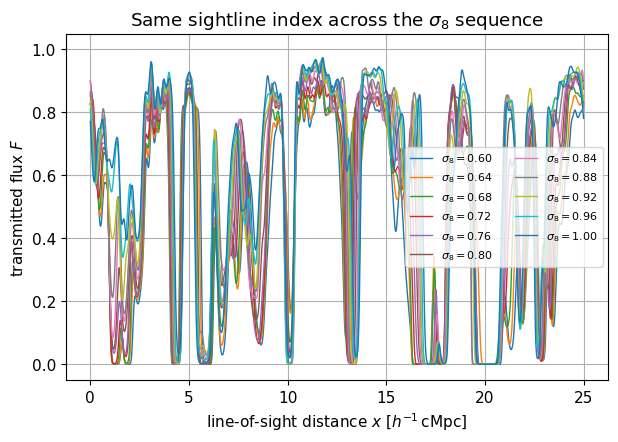

In [58]:
SIGHTLINE_INDEX = 0

plt.figure()

for sim_name, sigma8 in SIM_TABLE:
    tau_one = read_tau(spectra_file(sim_name), n_sightlines=SIGHTLINE_INDEX + 1)
    flux_one = tau_to_flux(tau_one)[SIGHTLINE_INDEX]
    plt.plot(x_demo, flux_one, lw=1.0, label=fr"$\sigma_8={sigma8:.2f}$")

plt.xlabel(r"line-of-sight distance $x$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.ylabel(r"transmitted flux $F$")
plt.title(fr"Same sightline index across the $\sigma_8$ sequence")
plt.ylim(-0.05, 1.05)
plt.legend(ncol=2, fontsize=8)
plt.show()

# 6. A simple mock-observation model

The spectra read from the simulation are idealized. To mimic two basic observational effects, we apply:

1. **Instrumental resolution**: a Gaussian smoothing kernel along the sightline.
2. **Flux noise**: independent Gaussian noise in normalized flux units.

The instrumental full width at half maximum is specified in km/s, because spectrograph resolution is often quoted this way. It is converted to pixels only for the smoothing operation. The subsequent analysis remains in $h^{-1}\mathrm{cMpc}$.

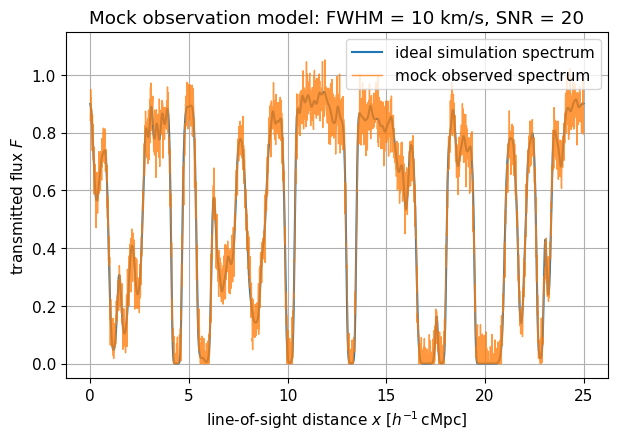

In [59]:
INSTRUMENT_FWHM_KMS = 10.0
SNR = 20.0


def add_mock_observation(
    flux,
    dv_kms,
    random_generator,
    snr=SNR,
    fwhm_kms=INSTRUMENT_FWHM_KMS,
):
    """Apply Gaussian instrumental smoothing and Gaussian flux noise."""
    sigma_kms = fwhm_kms / 2.355
    sigma_pixels = sigma_kms / dv_kms

    smooth_flux = gaussian_filter1d(flux, sigma=sigma_pixels, axis=1, mode="wrap")

    noise_sigma = 1.0 / snr
    noise = random_generator.normal(loc=0.0, scale=noise_sigma, size=smooth_flux.shape)
    noisy_flux = smooth_flux + noise

    return np.clip(noisy_flux, 0.0, 1.5)


demo_rng = np.random.default_rng(RANDOM_SEED)
mock_flux_demo = add_mock_observation(flux_demo, dv_demo, demo_rng)

plt.figure()
plt.plot(x_demo, flux_demo[0], lw=1.5, label="ideal simulation spectrum")
plt.plot(x_demo, mock_flux_demo[0], lw=1.0, alpha=0.8, label="mock observed spectrum")
plt.xlabel(r"line-of-sight distance $x$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.ylabel(r"transmitted flux $F$")
plt.title(fr"Mock observation model: FWHM = {INSTRUMENT_FWHM_KMS:.0f} km/s, SNR = {SNR:.0f}")
plt.ylim(-0.05, 1.15)
plt.legend()
plt.show()


# 7. One-dimensional flux power spectrum

The flux power spectrum summarizes fluctuations along the line of sight. First define the flux contrast,

$$
\delta_F(x)=\frac{F(x)}{\langle F\rangle}-1.
$$

For each sightline, we take a one-dimensional Fourier transform of the flux contrast $\delta_F$ along the line-of-sight direction. 

The squared Fourier amplitude gives the fluctuation power at each line-of-sight wavenumber $k$. 

Averaging this power over sightlines gives the one-dimensional flux power spectrum:

$$
P_{\mathrm{1D}}(k) \propto
\left\langle
\left|\widetilde{\delta_F}(k)\right|^2
\right\rangle.
$$

The precise normalization is not the focus here. The important point is the compression step:

$$
\{\text{many spectra}\}
\longrightarrow
\{P_{\mathrm{1D}}(k_1), P_{\mathrm{1D}}(k_2), \ldots, P_{\mathrm{1D}}(k_N)\}.
$$


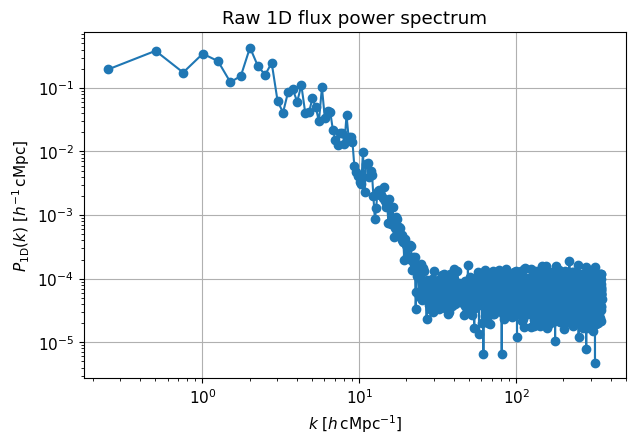

In [60]:
def flux_contrast(flux):
    """Return delta_F = F / <F> - 1."""
    mean_flux = flux.mean()
    return flux / mean_flux - 1.0


def flux_power_1d(flux, dx_mpc_h):
    """Compute a simple 1D flux power spectrum from many sightlines."""
    delta_flux = flux_contrast(flux)

    n_pixels = delta_flux.shape[1]
    box_length = n_pixels * dx_mpc_h

    k = 2.0 * np.pi * np.fft.rfftfreq(n_pixels, d=dx_mpc_h)
    fft_delta = np.fft.rfft(delta_flux, axis=1)

    # Continuous-transform-inspired normalization:
    # P(k) = |dx * FFT(delta_F)|^2 / L.
    power = np.abs(dx_mpc_h * fft_delta) ** 2 / box_length
    mean_power = power.mean(axis=0)

    # Drop the zero mode. It carries no useful fluctuation information here.
    return k[1:], mean_power[1:]


k_demo, power_demo = flux_power_1d(mock_flux_demo, dx_demo)

plt.figure()
plt.loglog(k_demo, power_demo, marker="o")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$P_{\rm 1D}(k)$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.title("Raw 1D flux power spectrum")
plt.show()


## Binning the power spectrum

The raw FFT returns many modes. For inference, it is useful to reduce this to a fixed-length vector of logarithmic $k$-bins:

$$
d =
\left(
\log P_{\mathrm{1D}}(k_1),
\log P_{\mathrm{1D}}(k_2),
\ldots,
\log P_{\mathrm{1D}}(k_N)
\right).
$$

This vector will become both the emulator target and the likelihood data vector.

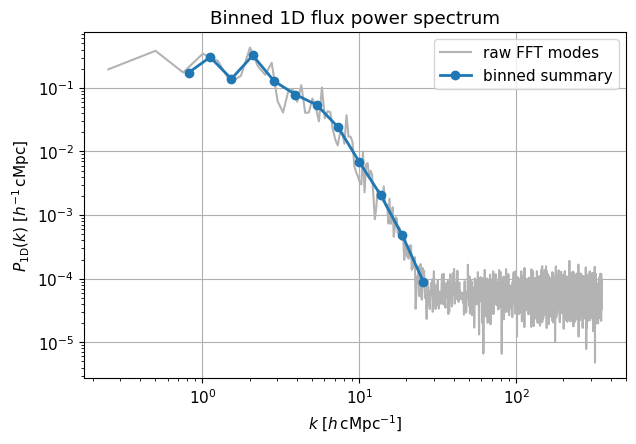

In [61]:
N_K_BINS = 12
K_MIN = 0.70
K_MAX = 30.0

K_EDGES = np.logspace(np.log10(K_MIN), np.log10(K_MAX), N_K_BINS + 1)
K_CENTERS = np.sqrt(K_EDGES[:-1] * K_EDGES[1:])


def bin_power_spectrum(k, power, bin_edges=K_EDGES):
    """Average the power spectrum in fixed logarithmic k-bins."""
    binned_power = []

    log_k = np.log(k)
    log_power = np.log(power + 1.0e-30)

    for k_low, k_high in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (k >= k_low) & (k < k_high)
        has_modes = np.any(in_bin)

        if has_modes:
            bin_mean = power[in_bin].mean()
            binned_power.append(bin_mean)
        else:
            # If a bin has no FFT mode, interpolate in log-log space.
            k_center = np.sqrt(k_low * k_high)
            bin_mean = np.exp(np.interp(np.log(k_center), log_k, log_power))
            binned_power.append(bin_mean)

    return np.asarray(binned_power)


binned_power_demo = bin_power_spectrum(k_demo, power_demo)

plt.figure()
plt.loglog(k_demo, power_demo, color="0.7", label="raw FFT modes")
plt.loglog(K_CENTERS, binned_power_demo, marker="o", lw=2, label="binned summary")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$P_{\rm 1D}(k)$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.title("Binned 1D flux power spectrum")
plt.legend()
plt.show()


# 8. Build the supervised learning dataset

Each CAMELS simulation has a known $\sigma_8$. From each simulation we compute several noisy estimates of $\log P_{\mathrm{1D}}(k)$ by splitting the sightlines into chunks.

For example, if a simulation contributes 5000 sightlines and the chunk size is 500, then it contributes 10 data vectors.

The supervised learning dataset is

$$
\left\{
\sigma_{8,i},\ \log P_{\mathrm{1D},i}(k)
\right\}.
$$

The first 4000 sightlines are used to construct emulator-training summaries. The last 1000 sightlines are held out for inference tests.

In [62]:
N_SIGHTLINES_PER_SIM = 5000
N_TRAINING_SIGHTLINES = 4000
N_TESTING_SIGHTLINES = 1000
CHUNK_SIZE = 500


def summarize_flux_chunk(flux_chunk, dx_mpc_h, dv_kms, random_generator):
    """Convert a chunk of spectra into one binned log-power vector."""
    mock_flux = add_mock_observation(flux_chunk, dv_kms, random_generator)
    k, power = flux_power_1d(mock_flux, dx_mpc_h)
    binned_power = bin_power_spectrum(k, power)
    return np.log(binned_power + 1.0e-12)


def split_into_chunks(array, chunk_size):
    """Yield consecutive chunks with the same number of sightlines."""
    n_complete = (array.shape[0] // chunk_size) * chunk_size

    for start in range(0, n_complete, chunk_size):
        stop = start + chunk_size
        yield array[start:stop]


def build_dataset():
    """Build the emulator and inference data vectors from all simulations."""
    random_generator = np.random.default_rng(RANDOM_SEED)

    sigma8_values = []
    log_power_vectors = []
    simulation_labels = []
    is_held_out = []

    for sim_name, sigma8 in SIM_TABLE:
        filename = spectra_file(sim_name)
        print(f"Processing {sim_name:8s}  sigma8={sigma8:.2f}")

        tau = read_tau(filename, n_sightlines=N_SIGHTLINES_PER_SIM)
        flux = tau_to_flux(tau)

        n_pixels = flux.shape[1]
        dx = comoving_pixel_width(n_pixels)
        dv = velocity_width_for_resolution(filename, n_pixels)

        test_start = N_TRAINING_SIGHTLINES
        test_stop = test_start + N_TESTING_SIGHTLINES

        training_flux = flux[:N_TRAINING_SIGHTLINES]
        testing_flux = flux[test_start:test_stop]
        flux_blocks = [(training_flux, False), (testing_flux, True)]

        for flux_block, held_out in flux_blocks:
            for flux_chunk in split_into_chunks(flux_block, CHUNK_SIZE):
                log_power = summarize_flux_chunk(flux_chunk, dx, dv, random_generator)

                if np.isfinite(log_power).all():
                    sigma8_values.append([sigma8])
                    log_power_vectors.append(log_power)
                    simulation_labels.append(sim_name)
                    is_held_out.append(held_out)

    return (
        np.asarray(sigma8_values, dtype=np.float32),
        np.asarray(log_power_vectors, dtype=np.float32),
        np.asarray(simulation_labels),
        np.asarray(is_held_out, dtype=bool),
    )


X, Y, labels, is_held_out = build_dataset()

emulator_training_mask = (~is_held_out) & np.isin(labels, EMULATOR_TRAINING_SIMS)
inference_test_mask = is_held_out & np.isin(labels, INFERENCE_TEST_SIMS)

print("\nDataset summary")
print("X shape:", X.shape, "  parameter values")
print("Y shape:", Y.shape, "  log-power vectors")
print("emulator-training examples:", emulator_training_mask.sum())
print("held-out inference examples:", inference_test_mask.sum())


Processing 1P_2_n5   sigma8=0.60
Processing 1P_2_n4   sigma8=0.64
Processing 1P_2_n3   sigma8=0.68
Processing 1P_2_n2   sigma8=0.72
Processing 1P_2_n1   sigma8=0.76
Processing 1P_2_0    sigma8=0.80
Processing 1P_2_1    sigma8=0.84
Processing 1P_2_2    sigma8=0.88
Processing 1P_2_3    sigma8=0.92
Processing 1P_2_4    sigma8=0.96
Processing 1P_2_5    sigma8=1.00

Dataset summary
X shape: (110, 1)   parameter values
Y shape: (110, 12)   log-power vectors
emulator-training examples: 64
held-out inference examples: 4


## How $\sigma_8$ changes the summary statistic

The plot below shows the average binned $\log P_{\mathrm{1D}}(k)$ for each simulation, using the non-held-out sightlines. This is the quantity the emulator will learn as a function of $\sigma_8$.

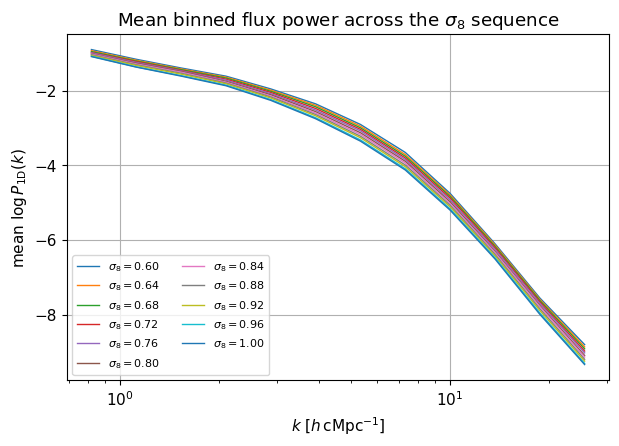

In [78]:
plt.figure()

for sim_name, sigma8 in SIM_TABLE:
    use = (labels == sim_name) & (~is_held_out)
    mean_log_power = Y[use].mean(axis=0)
    plt.plot(K_CENTERS, mean_log_power, lw=1, label=fr"$\sigma_8={sigma8:.2f}$")

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"mean $\log P_{\rm 1D}(k)$")
plt.title(fr"Mean binned flux power across the $\sigma_8$ sequence")
plt.legend(ncol=2, fontsize=8)
plt.show()

# 9. Train a differentiable emulator

The emulator is a small neural network that learns the relation

$$
m_\phi:\sigma_8 \mapsto \log P_{\mathrm{1D}}(k).
$$

In this notebook, `X` and `Y` are the supervised-learning dataset for that relation. They are paired row by row:

$$
X_i \longleftrightarrow Y_i.
$$

One row corresponds to one chunk of sightlines from one CAMELS simulation.

For one chunk:

1. The simulation has one known parameter value, $\sigma_8$.
2. We take `CHUNK_SIZE = 500` sightlines from that simulation.
3. Those 500 sightlines are converted into one binned power-spectrum vector.
4. The input row is the parameter value:

$$
X_i = [\sigma_8].
$$

5. The target row is the log power in the chosen $k$-bins:

$$
Y_i =
[\log P_{\mathrm{1D}}(k_1),
 \log P_{\mathrm{1D}}(k_2),
 \ldots,
 \log P_{\mathrm{1D}}(k_N)].
$$

So `X` is **not** the spectra and it is **not** the power spectrum. `X` only stores the input parameter labels. `Y` stores the measured summary statistic that the emulator should predict.

A concrete example is:

```text
X[i] = [0.80]
Y[i] = [log P(k1), log P(k2), ..., log P(k12)]
```

This means: for one chunk from the $\sigma_8=0.80$ simulation, the measured data vector is the 12-bin log-power vector in `Y[i]`.

Several rows can have the same value of `X` because one simulation is split into several chunks. Those chunks share the same true $\sigma_8$, but their measured power spectra differ slightly because they use different finite sets of sightlines and different mock noise.

The arrays used below are:

- `X`: all input parameter rows, with shape `(number of chunks, 1)`.
- `Y`: all target log-power rows, with shape `(number of chunks, number of k bins)`.
- `labels`: the simulation name for each row, used only for bookkeeping.
- `is_held_out`: whether that row came from sightlines reserved for inference tests.
- `emulator_training_mask`: selects the rows used to train the emulator.

The code below first forms

```python
X_emulator = X[emulator_training_mask]
Y_emulator = Y[emulator_training_mask]
```

These two arrays still have matching rows: `X_emulator[i]` is the $\sigma_8$ input, and `Y_emulator[i]` is the log-power target for the same chunk.

No standardization is applied in this version. The neural network directly receives physical $\sigma_8$ values and directly predicts $\log P_{\mathrm{1D}}(k)$. The network has `nn.Linear(1, 32)` at the input because each row of `X` contains one number, $\sigma_8$. It has `nn.Linear(32, Y.shape[1])` at the output because each row of `Y` contains one number for each $k$-bin.


In [64]:
X_emulator = X[emulator_training_mask]
Y_emulator = Y[emulator_training_mask]

split_rng = np.random.default_rng(RANDOM_SEED)
permutation = split_rng.permutation(len(X_emulator))

n_train = int(0.8 * len(permutation))
train_indices = permutation[:n_train]
validation_indices = permutation[n_train:]

X_train = X_emulator[train_indices]
Y_train = Y_emulator[train_indices]
X_validation = X_emulator[validation_indices]
Y_validation = Y_emulator[validation_indices]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_validation_t = torch.tensor(X_validation, dtype=torch.float32)
Y_validation_t = torch.tensor(Y_validation, dtype=torch.float32)

print("training examples  :", len(X_train))
print("validation examples:", len(X_validation))
print("output dimension   :", Y.shape[1])


training examples  : 51
validation examples: 13
output dimension   : 12


## What the training loop minimizes

After the train/validation split, `X_train_t` and `Y_train_t` are the PyTorch versions of the paired training rows:

```text
X_train_t[j]  ->  sigma8 for one chunk
Y_train_t[j]  ->  log-power vector for the same chunk
```

The model prediction

```python
prediction = emulator(X_train_t)
```

has the same shape as `Y_train_t`: one predicted log-power vector for each input $\sigma_8$ row.

The loss is the mean squared error between the predicted and target log-power vectors,

$$
\mathrm{loss}
=
\left\langle
\left(m_\phi(\sigma_8)-\log P_{\mathrm{1D}}\right)^2
\right\rangle,
$$

where the average is over training chunks and over $k$-bins. During this loop, `loss.backward()` computes gradients with respect to the neural-network weights $\phi$, and `optimizer.step()` updates those weights.

The physical parameter values in `X_train_t` are fixed labels. They are the inputs used to train the emulator; they are not being adjusted in this section.


In [65]:
emulator = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, Y.shape[1]),
)

optimizer = torch.optim.Adam(emulator.parameters(), lr=1.0e-2)

train_losses = []
validation_losses = []
recorded_epochs = []

for epoch in range(1001):
    emulator.train()
    optimizer.zero_grad()

    prediction = emulator(X_train_t)
    loss = torch.mean((prediction - Y_train_t) ** 2)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        emulator.eval()
        with torch.no_grad():
            validation_prediction = emulator(X_validation_t)
            validation_loss = torch.mean((validation_prediction - Y_validation_t) ** 2)

        recorded_epochs.append(epoch)
        train_losses.append(loss.item())
        validation_losses.append(validation_loss.item())

        if epoch % 200 == 0:
            print(
                f"epoch {epoch:4d} | "
                f"train loss = {loss.item():.4e} | "
                f"validation loss = {validation_loss.item():.4e}"
            )

epoch    0 | train loss = 2.1226e+01 | validation loss = 1.9867e+01
epoch  200 | train loss = 1.4602e-03 | validation loss = 1.6338e-03
epoch  400 | train loss = 9.0273e-04 | validation loss = 1.0851e-03
epoch  600 | train loss = 8.1272e-04 | validation loss = 1.0023e-03
epoch  800 | train loss = 8.0010e-04 | validation loss = 9.9292e-04
epoch 1000 | train loss = 7.9737e-04 | validation loss = 9.9097e-04


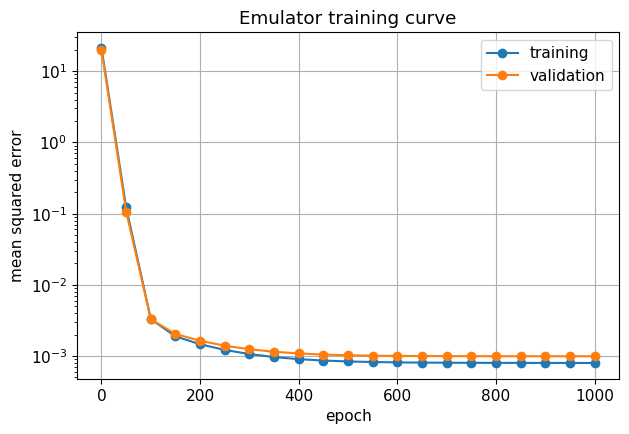

In [80]:
plt.figure()
plt.semilogy(recorded_epochs, train_losses, marker="o", label="training")
plt.semilogy(recorded_epochs, validation_losses, marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Emulator training curve")
plt.legend()
plt.show()

## Emulator prediction in physical units

The neural network now works directly in the physical units used by the dataset. Its input is $\sigma_8$, and its output is the predicted $\log P_{\mathrm{1D}}(k)$ vector.

The function `emulator_log_power_torch` is the differentiable forward model used later in the likelihood:

$$
\sigma_8
\longrightarrow
\text{neural network}
\longrightarrow
\log P_{\mathrm{1D}}(k).
$$

The NumPy wrapper below is only for plotting. The PyTorch function is the one used for differentiable inference.


In [67]:
def emulator_log_power_torch(sigma8):
    """Differentiable prediction: sigma8 -> log P_1D(k)."""
    sigma8 = sigma8.reshape(1, 1)
    return emulator(sigma8).reshape(-1)


def emulator_log_power_numpy(sigma8):
    """Numpy wrapper for plotting emulator predictions."""
    emulator.eval()

    with torch.no_grad():
        sigma8_t = torch.tensor([sigma8], dtype=torch.float32)
        return emulator_log_power_torch(sigma8_t).numpy()


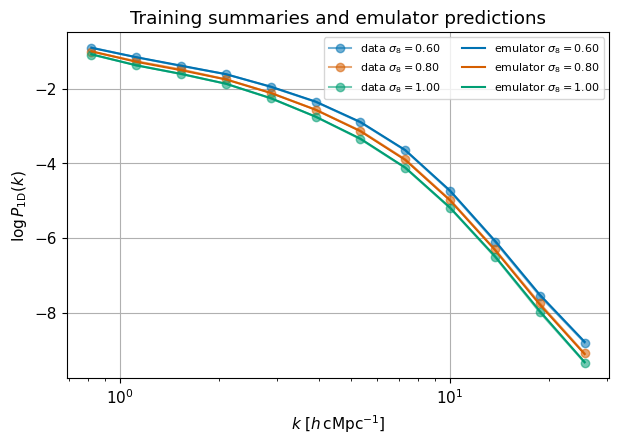

In [84]:
plt.figure()

sim_names = ["1P_2_n5", "1P_2_0", "1P_2_5"]
colors = ["#0072B2", "#D55E00", "#009E73"]

for sim_name, color in zip(sim_names, colors):
    sigma8 = SIM_TO_SIGMA8[sim_name]
    use = (labels == sim_name) & emulator_training_mask

    plt.plot(
        K_CENTERS,
        Y[use].mean(axis=0),
        marker="o",
        alpha=0.55,
        color=color,
        label=fr"data $\sigma_8={sigma8:.2f}$",
    )

for sigma8, color in zip([0.60, 0.80, 1.00], colors):
    prediction = emulator_log_power_numpy(sigma8)

    plt.plot(
        K_CENTERS,
        prediction,
        lw=1.5,
        color=color,
        label=fr"emulator $\sigma_8={sigma8:.2f}$",
    )

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$\log P_{\rm 1D}(k)$")
plt.title("Training summaries and emulator predictions")
plt.legend(ncol=2, fontsize=8)
plt.show()

# 10. Likelihood for $\sigma_8$

Now define a simple likelihood. For an observed summary vector

$$
d_{\mathrm{obs}} = \log P_{\mathrm{1D}}^\mathrm{obs}(k),
$$

and an emulator prediction

$$
m(\sigma_8)=\log P_{\mathrm{1D}}(k;\sigma_8),
$$

we use the diagonal Gaussian form

$$
\chi^2(\sigma_8)
=
\sum_i
\left[
\frac{d_{\mathrm{obs},i}-m_i(\sigma_8)}{s_i}
\right]^2.
$$

The quantities $s_i$ are empirical scale factors estimated from the training chunks. In a precision analysis, this would be replaced by a carefully estimated covariance matrix.

In [69]:
# Empirical diagonal uncertainty model.
sigma_log_power = Y_emulator.std(axis=0)
sigma_log_power = np.maximum(sigma_log_power, 0.05)
sigma_log_power_t = torch.tensor(sigma_log_power, dtype=torch.float32)


def chi2_for_observation(sigma8, observed_log_power):
    """Differentiable chi-square for one observed log-power vector."""
    observation_t = torch.tensor(observed_log_power, dtype=torch.float32)
    model_prediction = emulator_log_power_torch(sigma8)
    residual = (observation_t - model_prediction) / sigma_log_power_t
    return torch.sum(residual ** 2)


inference_cases = []

print("Held-out likelihood tests:")

for sim_name, color in zip(INFERENCE_TEST_SIMS, INFERENCE_COLORS):
    true_sigma8 = SIM_TO_SIGMA8[sim_name]

    use = is_held_out & (labels == sim_name)
    chunk_indices = np.where(use)[0]

    if len(chunk_indices) == 0:
        raise RuntimeError(f"No held-out data were found for {sim_name}.")

    observed_log_power = Y[chunk_indices].mean(axis=0)
    true_sigma8_t = torch.tensor([true_sigma8], dtype=torch.float32)
    chi2_at_true_sigma8 = chi2_for_observation(true_sigma8_t, observed_log_power).item()

    inference_cases.append(
        {
            "sim_name": sim_name,
            "true_sigma8": true_sigma8,
            "chi2_at_true_sigma8": chi2_at_true_sigma8,
            "chunk_indices": chunk_indices,
            "observed_log_power": observed_log_power,
            "color": color,
        }
    )

    print(
        f"{sim_name:8s}  "
        f"true sigma8 = {true_sigma8:.2f}  "
        f"chi2(true sigma8) = {chi2_at_true_sigma8:.4f}"
    )


Held-out likelihood tests:
1P_2_n2   true sigma8 = 0.72  chi2(true sigma8) = 0.5182
1P_2_2    true sigma8 = 0.88  chi2(true sigma8) = 0.2204


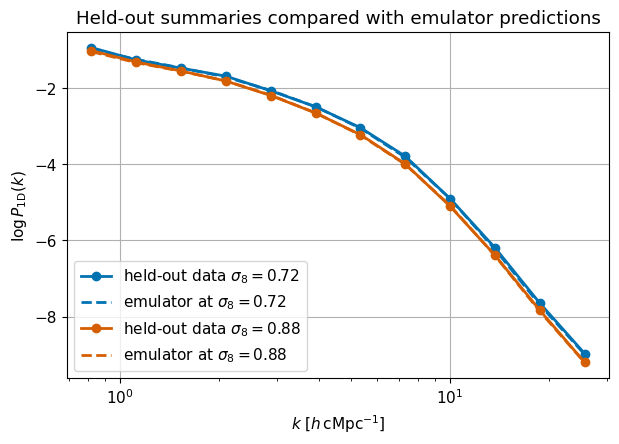

In [70]:
plt.figure()

for case in inference_cases:
    sigma8 = case["true_sigma8"]
    color = case["color"]
    plt.plot(
        K_CENTERS,
        case["observed_log_power"],
        marker="o",
        lw=2,
        color=color,
        label=fr"held-out data $\sigma_8={sigma8:.2f}$",
    )

    model_prediction = emulator_log_power_numpy(sigma8)
    plt.plot(
        K_CENTERS,
        model_prediction,
        linestyle="--",
        lw=2,
        color=color,
        label=fr"emulator at $\sigma_8={sigma8:.2f}$",
    )

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$\log P_{\rm 1D}(k)$")
plt.title("Held-out summaries compared with emulator predictions")
plt.legend()
plt.show()

# 11. Autograd: differentiating the likelihood

Up to this point, we have trained the emulator. The emulator has learned a smooth mapping

$$
\sigma_8 \longrightarrow \log P_{\mathrm{1D}}(k;\sigma_8).
$$

In this section, we do **not** update the emulator weights anymore. The neural network is now treated as a fixed, differentiable function. We use it only to predict the summary statistic for any trial value of $\sigma_8$.

The question we now ask is slightly different from training. During training, we asked: *what network weights best reproduce the training power spectra?* 

Here, we ask: *for this observed held-out power spectrum, how should $\sigma_8$ change in order to reduce the mismatch between the data and the emulator prediction?*

This mismatch is measured by $\chi^2(\sigma_8)$. Since $\chi^2$ is computed using the emulator output, and the emulator output depends on $\sigma_8$, PyTorch can follow the full chain

$$
\sigma_8
\longrightarrow
m(\sigma_8)
\longrightarrow
\chi^2(\sigma_8)
$$

and automatically compute

$$
\frac{\partial \chi^2}{\partial \sigma_8}.
$$

To make this possible, we create the trial value of $\sigma_8$ as a PyTorch tensor with

```python
requires_grad=True
```

This tells PyTorch to keep track of all operations involving this tensor. When we call `.backward()` on $\chi^2$, PyTorch differentiates the likelihood with respect to the input parameter $\sigma_8$.

The important point is that the derivative is with respect to the **physical parameter** $\sigma_8$, not with respect to the neural-network weights. This is the central differentiable-programming idea: once a trained emulator is differentiable, we can use gradients of the scientific objective directly with respect to the parameter we want to infer.


In [71]:
emulator.eval()

primary_case = inference_cases[0]

sigma8_trial = torch.tensor([0.72], dtype=torch.float32, requires_grad=True)
chi2_trial = chi2_for_observation(sigma8_trial, primary_case["observed_log_power"])

chi2_trial.backward()

print(f"trial sigma8          : {sigma8_trial.item():.4f}")
print(f"chi2(sigma8)          : {chi2_trial.item():.4f}")
print(f"d chi2 / d sigma8     : {sigma8_trial.grad.item():.4f}")

trial sigma8          : 0.7200
chi2(sigma8)          : 0.5182
d chi2 / d sigma8     : 17.9041


# 12. Gradient-based inference

We now use the derivative from the previous section to estimate $\sigma_8$. The idea is the same as fitting any model to data: try a value of the parameter, compare the prediction to the observation, and then adjust the parameter to improve the fit.

For a Gaussian likelihood,

$$
-\log p(d_{\mathrm{obs}} \mid \sigma_8)
=
\frac{1}{2}\chi^2(\sigma_8)
+
\mathrm{constant}.
$$

The constant does not depend on $\sigma_8$, so it does not affect where the likelihood is maximized. Therefore, maximizing the likelihood is equivalent to minimizing

$$
\frac{1}{2}\chi^2(\sigma_8).
$$

So the inference problem can be written as

$$
\widehat{\sigma}_8
=
\arg\min_{\sigma_8}
\frac{1}{2}\chi^2(\sigma_8).
$$

The optimizer below acts on one scalar parameter, $\sigma_8$. It starts from an initial guess, computes the current mismatch between the held-out data vector and the emulator prediction, and then uses the gradient to decide whether $\sigma_8$ should move upward or downward.

In each optimization step, the code does the following:

1. reset the old gradient using `optimizer.zero_grad()`;
2. compute the objective, $0.5\chi^2$;
3. call `.backward()` to compute the gradient with respect to $\sigma_8$;
4. call `optimizer.step()` to update $\sigma_8$;
5. keep $\sigma_8$ inside the emulator training range using `clamp_`.

The clamping step is important because the emulator was only trained over a finite range of $\sigma_8$. We should not ask it to extrapolate far outside that range.

The stored `sigma8_history` shows how the parameter estimate moves during optimization. The stored `objective_history` shows whether the mismatch is decreasing as the optimizer proceeds.


In [87]:
def run_gradient_inference(
    observed_log_power,
    start=SIGMA8_FIDUCIAL,
    n_steps=201,
    learning_rate=0.02,
):
    """Estimate sigma8 by minimizing 0.5 * chi2 with gradient descent."""
    sigma8_fit = torch.tensor([start], dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.Adam([sigma8_fit], lr=learning_rate)

    sigma8_history = []
    objective_history = []

    for _ in range(n_steps):
        optimizer.zero_grad()

        objective = 0.5 * chi2_for_observation(sigma8_fit, observed_log_power)
        objective.backward()
        optimizer.step()

        with torch.no_grad():
            sigma8_fit.clamp_(SIGMA8_MIN, SIGMA8_MAX)

        sigma8_history.append(sigma8_fit.item())
        objective_history.append(objective.item())

    return {
        "estimate": sigma8_fit.item(),
        "sigma8_history": np.asarray(sigma8_history),
        "objective_history": np.asarray(objective_history),
    }


for case in inference_cases:
    result = run_gradient_inference(case["observed_log_power"])
    case.update(result)

    print(
        f"{case['sim_name']:8s} | "
        f"true sigma8 = {case['true_sigma8']:.2f} | "
        f"gradient estimate = {case['estimate']:.4f}"
    )


1P_2_n2  | true sigma8 = 0.72 | gradient estimate = 0.7068
1P_2_2   | true sigma8 = 0.88 | gradient estimate = 0.8698


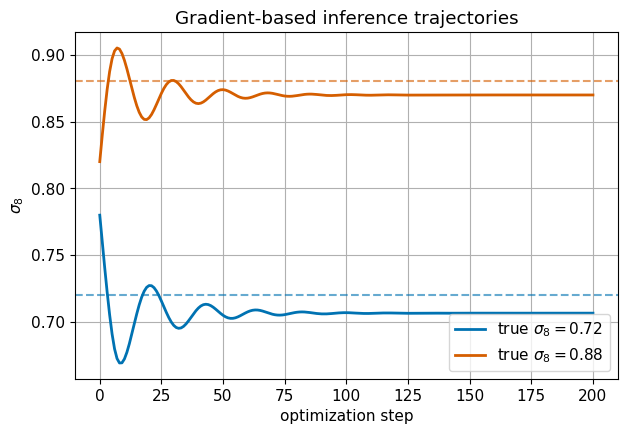

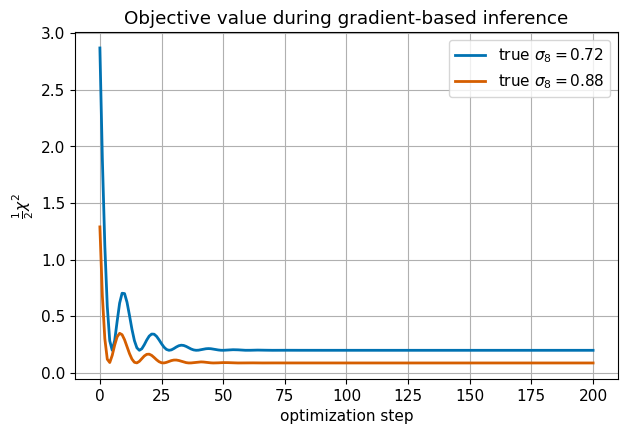

In [73]:
plt.figure()

for case in inference_cases:
    plt.plot(
        case["sigma8_history"],
        lw=2,
        color=case["color"],
        label=fr"true $\sigma_8={case['true_sigma8']:.2f}$",
    )
    plt.axhline(case["true_sigma8"], color=case["color"], linestyle="--", alpha=0.6)

plt.xlabel("optimization step")
plt.ylabel(r"$\sigma_8$")
plt.title(r"Gradient-based inference trajectories")
plt.legend()
plt.show()


plt.figure()

for case in inference_cases:
    plt.plot(
        case["objective_history"],
        lw=2,
        color=case["color"],
        label=fr"true $\sigma_8={case['true_sigma8']:.2f}$",
    )

plt.xlabel("optimization step")
plt.ylabel(r"$\frac{1}{2}\chi^2$")
plt.title("Objective value during gradient-based inference")
plt.legend()
plt.show()

# 13. Posterior grid as a check

The gradient-based method gives a best-fit estimate by moving downhill in the objective function. However, because this example has only one parameter, $\sigma_8$, we can also check the answer in a more direct way: evaluate the likelihood on a dense grid of possible $\sigma_8$ values.

This grid calculation asks: *if $\sigma_8$ were 0.60, what would the likelihood be? If it were 0.61, what would the likelihood be?* and so on across the emulator range. This gives the full one-dimensional posterior curve.

Assuming a flat prior over the emulator range,

$$
p(\sigma_8 \mid d)
\propto
\exp[-\frac{1}{2}\chi^2(\sigma_8)].
$$

Here, values of $\sigma_8$ with smaller $\chi^2$ get larger posterior probability, because they produce emulator predictions closer to the observed held-out summary statistic.

This grid calculation is not needed for autograd. It is included as a diagnostic check. It lets us compare three useful quantities:

1. the gradient-based estimate from the optimizer;
2. the MAP value, where the posterior is largest;
3. the posterior median and approximate 68% interval.

If the gradient-based estimate and the grid-based MAP are close, that gives confidence that the optimizer found the correct minimum. The posterior width also gives a rough sense of how tightly this summary statistic constrains $\sigma_8$ in this simplified exercise.


In [74]:
sigma8_grid = np.linspace(SIGMA8_MIN, SIGMA8_MAX, 401)


def posterior_grid(observed_log_power):
    """Evaluate the normalized posterior on a one-dimensional sigma8 grid."""
    chi2_values = []

    emulator.eval()
    with torch.no_grad():
        for sigma8 in sigma8_grid:
            sigma8_t = torch.tensor([sigma8], dtype=torch.float32)
            chi2 = chi2_for_observation(sigma8_t, observed_log_power)
            chi2_values.append(chi2.item())

    chi2_values = np.asarray(chi2_values)
    posterior = np.exp(-0.5 * (chi2_values - chi2_values.min()))
    posterior = posterior / np.trapz(posterior, sigma8_grid)

    cdf = np.cumsum(posterior)
    cdf = cdf / cdf[-1]

    return {
        "map": sigma8_grid[np.argmax(posterior)],
        "median": np.interp(0.50, cdf, sigma8_grid),
        "low_68": np.interp(0.16, cdf, sigma8_grid),
        "high_68": np.interp(0.84, cdf, sigma8_grid),
        "posterior": posterior,
    }


for case in inference_cases:
    result = posterior_grid(case["observed_log_power"])
    case.update(result)

    print(
        f"{case['sim_name']:8s} | "
        f"true sigma8 = {case['true_sigma8']:.2f} | "
        f"MAP = {case['map']:.4f} | "
        f"median = {case['median']:.4f} | "
        f"68% interval = [{case['low_68']:.4f}, {case['high_68']:.4f}]"
    )


1P_2_n2  | true sigma8 = 0.72 | MAP = 0.7070 | median = 0.7082 | 68% interval = [0.6712, 0.7470]
1P_2_2   | true sigma8 = 0.88 | MAP = 0.8700 | median = 0.8721 | 68% interval = [0.8265, 0.9204]


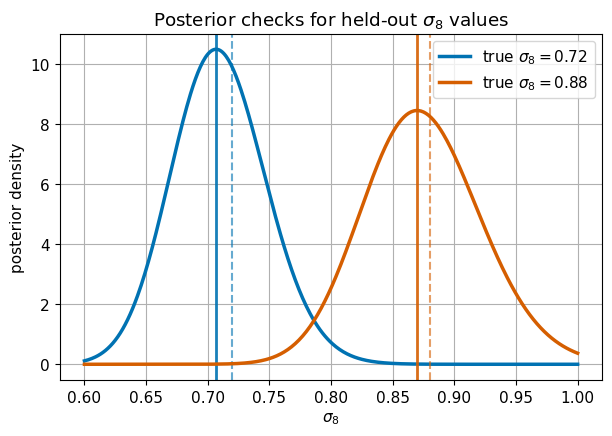

In [75]:
plt.figure()

for case in inference_cases:
    plt.plot(
        sigma8_grid,
        case["posterior"],
        lw=2.5,
        color=case["color"],
        label=fr"true $\sigma_8={case['true_sigma8']:.2f}$",
    )
    plt.axvline(case["map"], color=case["color"], lw=2, alpha=0.9)
    plt.axvline(case["true_sigma8"], color=case["color"], linestyle="--", alpha=0.6)

plt.xlabel(r"$\sigma_8$")
plt.ylabel(r"posterior density")
plt.title(r"Posterior checks for held-out $\sigma_8$ values")
plt.legend()
plt.show()

# 14. Conceptual summary

This notebook has demonstrated the complete structure of a differentiable Lyα forest inference pipeline:

$$
\tau(x)
\longrightarrow
F(x)=e^{-\tau(x)}
\longrightarrow
F_{\mathrm{mock}}(x)
\longrightarrow
P_{\mathrm{1D}}(k)
\longrightarrow
m_\phi(\sigma_8)
\longrightarrow
\chi^2(\sigma_8)
\longrightarrow
p(\sigma_8\mid d).
$$

The key ideas are:

1. A simulated spectrum can be converted into a statistical summary.
2. A supervised emulator can learn how that summary changes with a physical parameter.
3. A likelihood compares an observed summary with the emulator prediction.
4. If the emulator and likelihood are written in PyTorch, the likelihood is differentiable with respect to the physical parameter.
5. Autograd therefore provides gradients for parameter inference, not only for neural-network training.

This is a minimal example, but the same structure appears in many modern field-level and simulation-based inference problems.

## Further checks

The following variations help test which parts of the pipeline matter:

1. Decrease `SNR` from 20 to 10 and examine whether the posterior becomes broader.
2. Change `INSTRUMENT_FWHM_KMS` and identify which $k$-modes are most affected.
3. Train the emulator with fewer $\sigma_8$ values and examine whether interpolation becomes worse.
4. Replace the neural network with a polynomial fit in $\sigma_8$ and compare the result.

Each variation changes one component of the pipeline while leaving the rest fixed. This is the standard way to build intuition about a scientific inference workflow.